       SISTEMA DE ROTAS E MALHA AÉREA REGIONAL
[01] Santarém (PA)
[02] Penedo (AL)
[03] Picos (PI)
[04] Passo Fundo (RS)
[05] Diamantina (MG)
[06] Cascavel (PR)
[07] Sobral (CE)
[08] Rio Verde (GO)
[09] Ji-Paraná (RO)
[10] Blumenau (SC)
[11] Barretos (SP)
[12] Garanhuns (PE)
[13] Resende (RJ)
[14] Barreiras (BA)
[15] Rondonópolis (MT)
[16] Linhares (ES)
[17] Dourados (MS)
[18] Campina Grande (PB)
[19] Mossoró (RN)
[20] Gurupi (TO)

Digite o número da CIDADE DE ORIGEM: 2
Digite o número da CIDADE DE DESTINO: 7

✅ ROTA ENCONTRADA com o menor número de conexões!
Penedo (AL) ➔ Campina Grande (PB) ➔ Sobral (CE)
Número total de trechos: 2


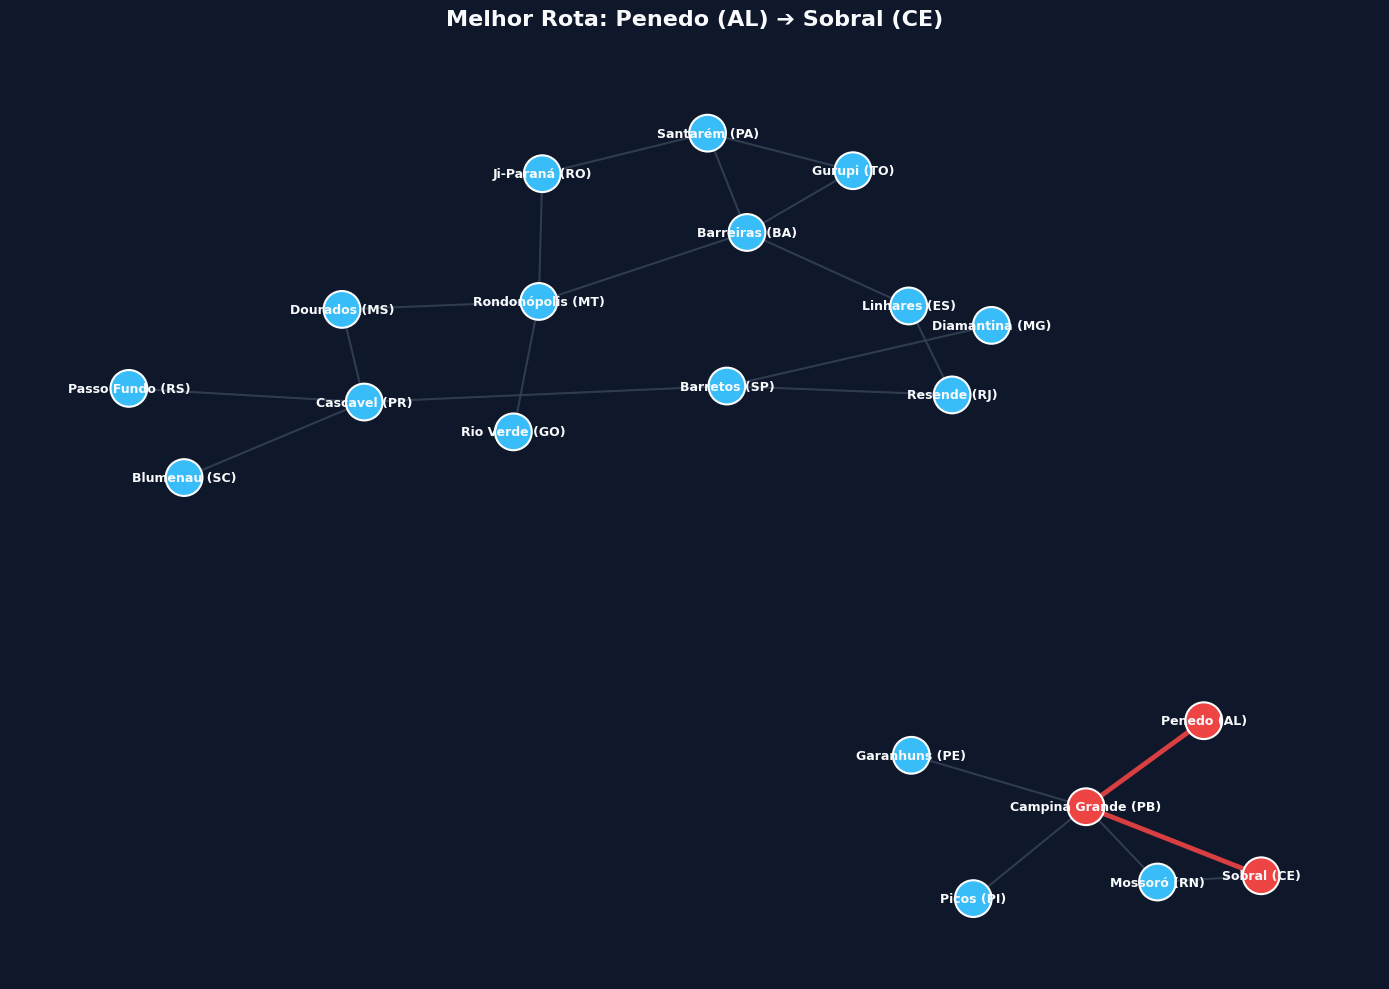

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# 1. Lista das 20 cidades
cidades = [
    "Santarém (PA)", "Penedo (AL)", "Picos (PI)", "Passo Fundo (RS)",
    "Diamantina (MG)", "Cascavel (PR)", "Sobral (CE)", "Rio Verde (GO)",
    "Ji-Paraná (RO)", "Blumenau (SC)", "Barretos (SP)", "Garanhuns (PE)",
    "Resende (RJ)", "Barreiras (BA)", "Rondonópolis (MT)", "Linhares (ES)",
    "Dourados (MS)", "Campina Grande (PB)", "Mossoró (RN)", "Gurupi (TO)"
]

# 2. Definição das conexões aéreas (diretas ou integradas)
conexoes_existentes = [
    ("Santarém (PA)", "Ji-Paraná (RO)"),
    ("Santarém (PA)", "Gurupi (TO)"),
    ("Santarém (PA)", "Barreiras (BA)"),
    ("Cascavel (PR)", "Passo Fundo (RS)"),
    ("Cascavel (PR)", "Blumenau (SC)"),
    ("Cascavel (PR)", "Dourados (MS)"),
    ("Cascavel (PR)", "Barretos (SP)"),
    ("Campina Grande (PB)", "Mossoró (RN)"),
    ("Campina Grande (PB)", "Garanhuns (PE)"),
    ("Campina Grande (PB)", "Penedo (AL)"),
    ("Campina Grande (PB)", "Picos (PI)"),
    ("Campina Grande (PB)", "Sobral (CE)"),
    ("Rondonópolis (MT)", "Rio Verde (GO)"),
    ("Rondonópolis (MT)", "Ji-Paraná (RO)"),
    ("Rondonópolis (MT)", "Dourados (MS)"),
    ("Rondonópolis (MT)", "Barreiras (BA)"),
    ("Barreiras (BA)", "Gurupi (TO)"),
    ("Barreiras (BA)", "Linhares (ES)"),
    ("Barretos (SP)", "Resende (RJ)"),
    ("Barretos (SP)", "Diamantina (MG)"),
    ("Linhares (ES)", "Resende (RJ)"),
    ("Mossoró (RN)", "Sobral (CE)"),
]

# 3. Matriz de Adjacência
n = len(cidades)
matriz_adjacencia = np.zeros((n, n), dtype=int)
mapa_indices = {cidade: idx for idx, cidade in enumerate(cidades)}

for origem, destino in conexoes_existentes:
    i, j = mapa_indices[origem], mapa_indices[destino]
    matriz_adjacencia[i][j] = 1
    matriz_adjacencia[j][i] = 1

# 4. Construção do Grafo no NetworkX
G = nx.Graph()
for cidade in cidades:
    G.add_node(cidade)
for origem, destino in conexoes_existentes:
    G.add_edge(origem, destino)


def encontrar_e_plotar_rota(cidade_origem, cidade_destino):
    # Verifica se existem o caminho entre as cidades
    if not nx.has_path(G, cidade_origem, cidade_destino):
        print(f"\n❌ Não existe nenhuma rota disponível entre '{cidade_origem}' e '{cidade_destino}'.")
        caminho_menor = []
    else:
        # Calcula o menor caminho (menor número de conexões/escalas)
        caminho_menor = nx.shortest_path(G, source=cidade_origem, target=cidade_destino)
        print("\n✅ ROTA ENCONTRADA com o menor número de conexões!")
        print(" ➔ ".join(caminho_menor))
        print(f"Número total de trechos: {len(caminho_menor) - 1}")

    # Conjunto das arestas da menor rota
    arestas_rota = set()
    if caminho_menor:
        for k in range(len(caminho_menor) - 1):
            u, v = caminho_menor[k], caminho_menor[k+1]
            arestas_rota.add((u, v))
            arestas_rota.add((v, u))

    # Definir cores para os Nós (Cidades)
    cores_nos = []
    for no in G.nodes():
        if no in caminho_menor:
            cores_nos.append('#ef4444')  # Vermelho para cidades da rota
        else:
            cores_nos.append('#38bdf8')  # Azul claro para demais cidades

    # Definir cores e larguras para as Arestas (Conexões)
    cores_arestas = []
    larguras_arestas = []
    for u, v in G.edges():
        if (u, v) in arestas_rota:
            cores_arestas.append('#ef4444')  # Vermelho para a rota escolhida
            larguras_arestas.append(3.5)
        else:
            cores_arestas.append('#334155')  # Cinza escuro para rotas normais
            larguras_arestas.append(1.5)

    # Plotagem
    fig, ax = plt.subplots(figsize=(14, 10), facecolor='#0f172a')
    ax.set_facecolor('#0f172a')

    pos = nx.spring_layout(G, seed=42, k=0.45)

    # Desenhar Nós
    nx.draw_networkx_nodes(
        G, pos,
        node_size=700,
        node_color=cores_nos,
        edgecolors='#ffffff',
        linewidths=1.5,
        ax=ax
    )

    # Desenhar Arestas
    nx.draw_networkx_edges(
        G, pos,
        width=larguras_arestas,
        edge_color=cores_arestas,
        alpha=0.9,
        ax=ax
    )

    # Desenhar Rótulos
    nx.draw_networkx_labels(
        G, pos,
        font_size=9,
        font_color='#f8fafc',
        font_weight='bold',
        ax=ax
    )

    titulo = f"Melhor Rota: {cidade_origem} ➔ {cidade_destino}" if caminho_menor else "Sem Conexão Aérea"
    plt.title(titulo, fontsize=16, color='#f8fafc', fontweight='bold', pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


# 5. Menu Interativo de Seleção
if __name__ == "__main__":
    print("=" * 60)
    print("       SISTEMA DE ROTAS E MALHA AÉREA REGIONAL")
    print("=" * 60)
    for idx, c in enumerate(cidades, 1):
        print(f"[{idx:02d}] {c}")
    print("=" * 60)

    try:
        idx_origem = int(input("\nDigite o número da CIDADE DE ORIGEM: ")) - 1
        idx_destino = int(input("Digite o número da CIDADE DE DESTINO: ")) - 1

        if 0 <= idx_origem < n and 0 <= idx_destino < n:
            origem = cidades[idx_origem]
            destino = cidades[idx_destino]
            encontrar_e_plotar_rota(origem, destino)
        else:
            print("❌ Número de cidade inválido.")
    except ValueError:
        print("❌ Entrada inválida. Digite um número.")